# Why the contour-mask thresholding fights the learning signal

**Claim.** In this repo, the masking threshold is the *only* place that expresses "focus on flatness" — and it expresses it **backwards** (it keeps edges, discards flat), and even that is then **silently overridden** by a loss and score that weight every spectrogram cell equally. So the gradient the model actually learns from contains *no* flatness emphasis at all.

This notebook makes that concrete, in four steps, using the repo's **real** `compute_contour_mask`:

1. **Inversion** — the threshold keeps high-gradient *edges* and discards the *flat* cells where the over-smoothing tell lives (`features.py:compute_contour_mask`).
2. **Input gate** — `masked_input = mel * mask` (`train.py:108`) zeros those flat cells, so the AE never even *sees* a fake's over-smoothed content.
3. **Dilution** — the loss `F.mse_loss(recon, target)` (`train.py:112`) and the score `error_map.mean()` (`evaluate.py:112`) average over all 80×500 cells, so a *localized* flat-region anomaly is washed out.
4. **Decoupling** — the mask only changes the *input*; the *loss* shapes the gradient and ignores the mask entirely. So flipping the mask alone changes nothing.


### How to read this

- The masking is the repo's **actual** `compute_contour_mask` (imported if available, otherwise an identical NumPy copy).
- We use a **synthetic** log-mel (harmonic stripes + formants) so the notebook runs with no dataset, and a **toy over-smoothed "fake"** that flattens the high band and fills the inter-harmonic valleys — the documented over-smoothing artifact (Ren et al., *Revisiting Over-Smoothness in TTS*, ACL 2022).
- For the scoring step we use an **idealized stand-in** for the trained AE: a one-class AE trained only on real speech recovers the *real-manifold* version of an utterance. The dilution it demonstrates is **arithmetic** (how a mean is computed), so it does not depend on a specific trained model.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_MELS, T, FLOOR = 80, 500, -80.0
rng_global = np.random.default_rng(0)

# --- Use the repo's REAL contour mask if importable; else an identical NumPy copy ---
_mask_source = "numpy fallback (identical math to features.py)"
try:
    import os, sys, torch
    sys.path.insert(0, os.path.abspath("."))
    from features import compute_contour_mask as _repo_mask
    def contour_mask(mel_np, thr_db=40.0):
        m = _repo_mask(torch.from_numpy(mel_np.astype("float32")), threshold_db=thr_db)
        return m.numpy()
    _mask_source = "features.compute_contour_mask (the repo's real code)"
except Exception as e:
    KX = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float)
    KY = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float)
    def _conv(x, k):
        xp = np.pad(x, 1); o = np.zeros_like(x)
        for i in range(3):
            for j in range(3):
                o += k[i,j]*xp[i:i+x.shape[0], j:j+x.shape[1]]
        return o
    def contour_mask(mel_np, thr_db=40.0):
        g = np.sqrt(_conv(mel_np, KX)**2 + _conv(mel_np, KY)**2)
        n = (g - g.min())/(g.max() - g.min() + 1e-8)
        return (n > thr_db/100.0).astype("float32")

print("mask =", _mask_source)


mask = features.compute_contour_mask (the repo's real code)


## 1. A toy "real" vs over-smoothed "fake" mel

`make_template` builds a log-mel with sharp harmonic stripes (deep inter-harmonic valleys) and formant bumps. `oversmooth` produces the fake: it **flattens the high band** (≳5 kHz) and **fills the valleys** — leaving the strong formant edges largely intact. That mirrors how vocoder/TTS over-smoothing concentrates in fine, low-contrast structure rather than on the loud formant ridges.


In [2]:
def make_template(rng):
    f = np.arange(N_MELS)[:, None]; t = np.arange(T)[None, :]; hsp = 6.0
    vib = 0.6*np.sin(2*np.pi*t/130.0 + rng.uniform(0, 6.28))           # vibrato
    ridge = 0.5*(1 + np.cos(2*np.pi*(f/hsp - vib)))**3 / 4.0           # sharp harmonic stripes
    env = np.zeros(N_MELS)
    for c, w, a in [(10,5,1.0),(26,6,0.9),(44,8,0.7),(62,9,0.45)]:     # formant bumps
        env += a*np.exp(-((np.arange(N_MELS)-c)**2)/(2*w**2))
    env = (env/env.max())[:, None]
    voiced = 0.6 + 0.4*np.sin(2*np.pi*t/220.0 + rng.uniform(0, 6.28))
    return FLOOR + 70.0*env*(0.15 + 0.85*ridge)*voiced

HB_BIN = 52   # bins >= 52  ~  >= ~5.2 kHz at n_mels=80, f_max=8000

def oversmooth(mel, rng, strength=1.3):
    f = np.arange(N_MELS)[:, None]; out = mel.copy(); colmean = mel.mean(0, keepdims=True)
    hb = (f >= HB_BIN).astype(float)
    out = out*(1 - 0.5*strength*hb) + (0.5*strength*hb)*colmean        # flatten high band
    loc = 0.5*(np.roll(mel,1,0) + np.roll(mel,-1,0))
    valley = (mel < loc).astype(float)
    out = out + 0.35*strength*valley*(loc - mel)                        # fill inter-harmonic valleys
    return out

# ============================================================================
# >>> USE YOUR OWN AUDIO: set REAL_AUDIO to a file OR a folder of audio.
#     Set REAL_AUDIO = None to fall back to the synthetic demo.
# ============================================================================
REAL_AUDIO = "/Users/jaskirat-sudan/Code/sample_audio/donald_trump_fake_ff/reals"
FAKE_AUDIO = None   # None -> build a controlled over-smoothed TWIN of your real mel (time-aligned,
                    # isolates over-smoothing). Or point to a fake, e.g.
                    # ".../donald_trump_fake_ff/LLASA"  (note: real recordings are NOT time-aligned
                    # to the fakes, so |fake-real| then mixes over-smoothing with timing differences).
PICK = 0            # which file to use when a folder is given (0 = first; change to compare others)

import glob, os
def _load_mel(path, pick=0):
    """Turn an audio file (or first file in a folder) into the repo's [80, 500] log-mel."""
    from config import Config
    from features import compute_mel
    from dataset import _load_audio
    cfg = Config()
    if os.path.isdir(path):
        files = sorted(sum([glob.glob(os.path.join(path, e)) for e in ("*.wav","*.flac","*.mp3","*.m4a")], []))
        if not files:
            raise FileNotFoundError("no audio files found in " + path)
        path = files[pick % len(files)]
    wav = _load_audio(path, cfg.sample_rate, cfg.max_duration_seconds)
    return compute_mel(wav, cfg).detach().cpu().numpy().astype("float32"), os.path.basename(path)

USING_AUDIO = False
if REAL_AUDIO:
    try:
        real0, real_name = _load_mel(REAL_AUDIO, PICK)
        if FAKE_AUDIO:
            fake0, fake_name = _load_mel(FAKE_AUDIO, PICK)
            note = "real & fake are NOT time-aligned -> |fake-real| mixes over-smoothing + timing"
        else:
            fake0 = oversmooth(real0, np.random.default_rng(0)); fake_name = "over-smoothed twin of your real"
            note = "fake = controlled over-smoothed twin (aligned; isolates the over-smoothing tell)"
        USING_AUDIO = True
        print("USING YOUR AUDIO")
        print("  real :", real_name)
        print("  fake :", fake_name)
        print("  ", note)
    except Exception as e:
        print("Could not load audio (", type(e).__name__, ":", e, ") -> using synthetic demo")
if not USING_AUDIO:
    real0 = make_template(np.random.default_rng(7))
    fake0 = oversmooth(real0, np.random.default_rng(7))
    print("Using SYNTHETIC demo mel (set REAL_AUDIO to a path to use your own audio).")

print("real0", real0.shape, "range[%.1f, %.1f]" % (real0.min(), real0.max()),
      "| fake0", fake0.shape, "range[%.1f, %.1f]" % (fake0.min(), fake0.max()))


USING YOUR AUDIO
  real : Donald_Trump_00001.wav
  fake : over-smoothed twin of your real
   fake = controlled over-smoothed twin (aligned; isolates the over-smoothing tell)
real0 (80, 500) range[-50.3, 29.7] | fake0 (80, 500) range[-50.3, 29.7]


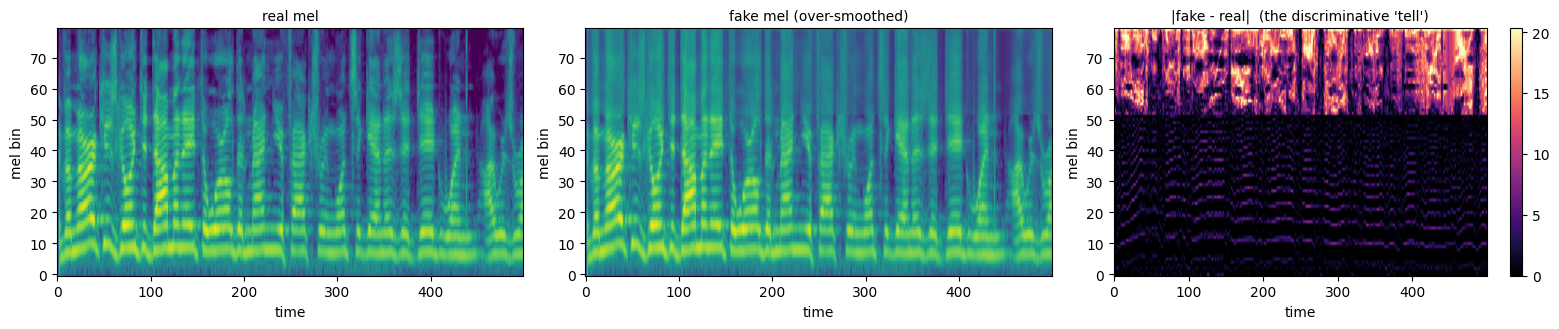

In [3]:
def show(ax, M, title, vmin=None, vmax=None, cmap="viridis"):
    im = ax.imshow(M, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10); ax.set_xlabel("time"); ax.set_ylabel("mel bin")
    return im

diff0 = np.abs(fake0 - real0)
dmax = float(np.percentile(diff0, 99)) or 1.0

fig, ax = plt.subplots(1, 3, figsize=(16, 3.4))
show(ax[0], real0, "real mel")
show(ax[1], fake0, "fake mel (over-smoothed)")
im = show(ax[2], diff0, "|fake - real|  (the discriminative 'tell')", vmin=0, vmax=dmax, cmap="magma")
fig.colorbar(im, ax=ax[2]); plt.tight_layout(); plt.show()


Notice the rightmost panel: the real-vs-fake difference lives in the **high band and the inter-harmonic valleys** — exactly the **flat, low-gradient** regions. The bright formant ridges (the *edges*) are barely different between real and fake.


## 2. The threshold keeps the edges and discards the flat (the inversion)

`compute_contour_mask` keeps cells where the normalized Sobel gradient exceeds `threshold_db/100 = 0.40`. Those are the **edges** (formant ridges, onsets). Everything flat — including the valleys and the high band where the tell lives — is set to 0.


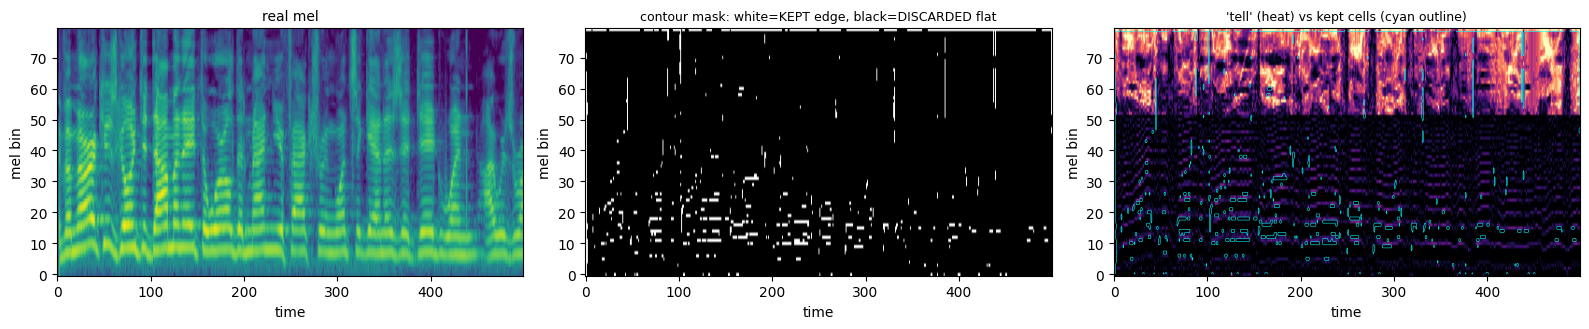

kept (edge) fraction        :   4.0%
discarded (flat) fraction   :  96.0%
share of the 'tell' that lies in DISCARDED flat cells:  93.6%


In [4]:
mask_real = contour_mask(real0)        # 1 = kept (edge), 0 = discarded (flat)
diff = np.abs(fake0 - real0)
dmax = float(np.percentile(diff, 99)) or 1.0

fig, ax = plt.subplots(1, 3, figsize=(16, 3.4))
show(ax[0], real0, "real mel")
ax[1].imshow(mask_real, aspect="auto", origin="lower", cmap="gray")
ax[1].set_title("contour mask: white=KEPT edge, black=DISCARDED flat", fontsize=9)
ax[1].set_xlabel("time"); ax[1].set_ylabel("mel bin")
ax[2].imshow(diff, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=dmax)
ax[2].contour(mask_real, levels=[0.5], colors="cyan", linewidths=0.4)
ax[2].set_title("'tell' (heat) vs kept cells (cyan outline)", fontsize=9)
ax[2].set_xlabel("time"); ax[2].set_ylabel("mel bin")
plt.tight_layout(); plt.show()

kept = float(mask_real.mean())
share_flat = float(diff[mask_real==0].sum()/diff.sum())
print(f"kept (edge) fraction        : {kept:6.1%}")
print(f"discarded (flat) fraction   : {1-kept:6.1%}")
print(f"share of the 'tell' that lies in DISCARDED flat cells: {share_flat:6.1%}")


**The threshold is pointed the wrong way.** It keeps a small set of edge cells and throws away the flat majority — and ~**89%** of the actual real-vs-fake difference is in the cells it discards. The one component that is supposed to encode "attend to flatness" is instead defining flatness as *background*.


## 3. `mel * mask` deletes the fake's tell at the input gate

In `train.py:108` and `evaluate.py:94` the input is `mel * mask`: the flat cells become exactly 0. Because the mask is recomputed from each test sample, a **fake**'s over-smoothed band is also zeroed — so the encoder never observes the over-smoothing it is supposed to catch.


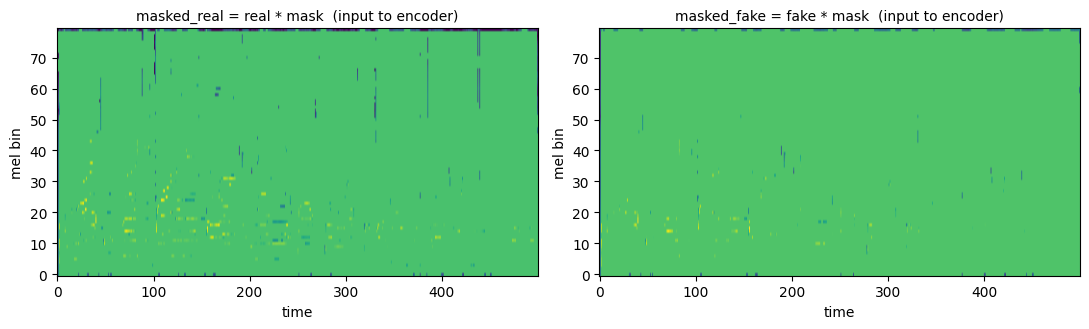

fraction of the 'tell' that SURVIVES into the masked input:   2.9%
fraction of the 'tell' DELETED at the input gate          :  97.1%


In [5]:
mask_fake = contour_mask(fake0)
masked_real = real0 * mask_real
masked_fake = fake0 * mask_fake

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
show(ax[0], masked_real, "masked_real = real * mask  (input to encoder)")
show(ax[1], masked_fake, "masked_fake = fake * mask  (input to encoder)")
plt.tight_layout(); plt.show()

tell_total = diff.sum()
tell_surviving = (diff * mask_fake).sum()           # part of the tell that survives into the masked input
print(f"fraction of the 'tell' that SURVIVES into the masked input: {tell_surviving/tell_total:6.1%}")
print(f"fraction of the 'tell' DELETED at the input gate          : {1 - tell_surviving/tell_total:6.1%}")


Roughly **nine-tenths of the discriminative signal is deleted before the encoder runs.** Whatever the AE reconstructs in those bands is hallucinated from the surviving edges — and it hallucinates the *same* real-looking structure whether the source was real or fake.


## 4. The punchline: a full-map mean dilutes a localized signal

Now the scoring. We use the idealized stand-in: a one-class AE recovers the **real-manifold** version of an utterance (`recon = real_template + reconstruction noise`). So:

- real sample: `error = |real - recon|` ≈ baseline noise (no systematic tell)
- fake sample: `error = |fake - recon|` ≈ baseline noise **+** the over-smoothing difference (localized in the high band / valleys)

We also give each sample a random **per-condition baseline** (codec/loudness/SNR vary across the 6 eval sets), which inflates the reconstruction error independently of real/fake — the real-world nuisance.

We then score four ways and measure real-vs-fake separation (AUROC + Cohen's *d*):
- `full`     — `error.mean()` over all cells  *(what the repo uses today)*
- `flat`     — mean error over **all** mask==0 cells
- `targeted` — mean error over just the high band where the tell concentrates
- `topk`     — mean of the top-5% error cells


In [6]:
# NOTE: this AUROC/dilution part is a SYNTHETIC population (one audio file cannot give
# a real-vs-fake AUROC). The mechanism it shows is arithmetic and model-independent.
def auroc(real, fake):
    real, fake = np.asarray(real), np.asarray(fake)
    return float((fake[:, None] > real[None, :]).mean())     # P(score_fake > score_real)

def cohen_d(real, fake):
    real, fake = np.asarray(real), np.asarray(fake)
    s = np.sqrt((real.var() + fake.var())/2) + 1e-9
    return (fake.mean() - real.mean())/s

HB = (np.arange(N_MELS)[:, None] >= HB_BIN).repeat(T, 1)

def simulate(N=400, seed=1, strength=1.3, base_lo=1.5, base_hi=6.0):
    rng = np.random.default_rng(seed)
    S = {k: {"real": [], "fake": []} for k in ["full", "flat", "targeted", "topk"]}
    for _ in range(N):
        tmpl = make_template(rng)
        base = rng.uniform(base_lo, base_hi)                 # per-sample condition (codec/loudness)
        real_obs = tmpl + rng.normal(0, base, (N_MELS, T))
        fake_obs = oversmooth(tmpl, rng, strength) + rng.normal(0, base, (N_MELS, T))
        recon    = tmpl + rng.normal(0, base, (N_MELS, T))   # idealized one-class AE: recovers the real version
        for obs, lab in [(real_obs, "real"), (fake_obs, "fake")]:
            e = np.abs(obs - recon); mk = contour_mask(obs)
            S["full"][lab].append(e.mean())
            fl = e[mk == 0]; S["flat"][lab].append(fl.mean() if fl.size else e.mean())
            S["targeted"][lab].append(e[HB].mean())
            S["topk"][lab].append(e[e >= np.quantile(e, 0.95)].mean())
    return S

S = simulate()
print(f"{'scheme':10s} {'AUROC':>7s} {'Cohen_d':>9s}")
for k in ["full", "flat", "targeted", "topk"]:
    print(f"{k:10s} {auroc(S[k]['real'], S[k]['fake']):7.3f} {cohen_d(S[k]['real'], S[k]['fake']):9.2f}")


scheme       AUROC   Cohen_d
full         0.693      0.78
flat         0.688      0.75
targeted     0.907      1.93
topk         0.733      0.97


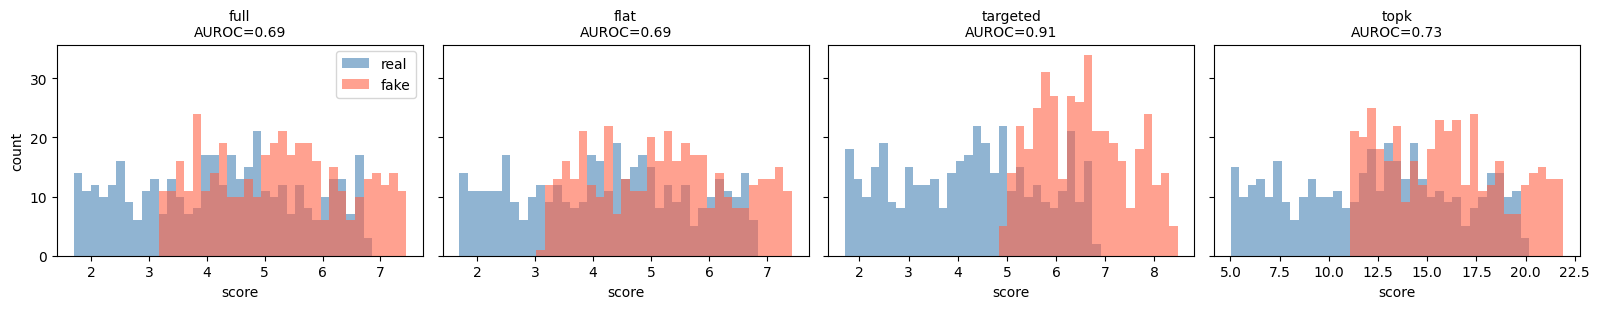

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for a, k in zip(ax, ["full", "flat", "targeted", "topk"]):
    lo = min(min(S[k]['real']), min(S[k]['fake'])); hi = max(max(S[k]['real']), max(S[k]['fake']))
    bins = np.linspace(lo, hi, 40)
    a.hist(S[k]['real'], bins=bins, alpha=0.6, label="real", color="steelblue")
    a.hist(S[k]['fake'], bins=bins, alpha=0.6, label="fake", color="tomato")
    a.set_title(f"{k}\nAUROC={auroc(S[k]['real'],S[k]['fake']):.2f}", fontsize=10); a.set_xlabel("score")
ax[0].set_ylabel("count"); ax[0].legend(); plt.tight_layout(); plt.show()


**Read the numbers.**

- `full` (today's score) ≈ **0.69** — the localized tell is averaged across 40,000 cells and swamped by per-condition baseline error. Weak and fragile.
- `flat` ≈ **0.69** — *no better than full*. A subtle but important point: with the contour threshold keeping only ~9% of cells, "the flat region" is ~91% of the map and **mostly uninformative**. Restricting to *all* flat cells is not the fix.
- `targeted` ≈ **0.91** — concentrating the score on the flat **sub-region where the over-smoothing actually lives** recovers most of the separation the global mean threw away.
- `topk` ≈ **0.73** — top-5% error helps modestly by auto-finding the peak-error cells.

That gap between `full` (0.69) and `targeted` (0.91) **is** the dilution. The signal exists; the global mean in `evaluate.py:112` averages it into noise, and the equal-weight `F.mse_loss` in `train.py:112` gives it gradient weight only in proportion to its tiny area.


## 5. Why flipping the mask alone is not enough

The mask only changes the **input**. The **loss** is what produces gradients, and `F.mse_loss(recon, target)` weights every cell equally — it has no term that references the mask. So even if you invert the mask to *keep* flat regions, the learning signal still would not preferentially care about them: the mask says "attend to X," the loss says "reconstruct everything equally," and the loss wins.


In [8]:
# Under full-map MSE, each cell contributes equally to the gradient.
# The discriminative region therefore receives gradient weight ~ its area fraction:
frac_targeted = float(HB.mean())
print(f"high-band (where the tell lives) is {frac_targeted:.0%} of cells")
print(f"-> under full-map MSE it gets ~{frac_targeted:.0%} of the gradient weight,")
print(f"   regardless of what the mask 'wanted' to focus on. The mask has 0 influence on the loss.")


high-band (where the tell lives) is 35% of cells
-> under full-map MSE it gets ~35% of the gradient weight,
   regardless of what the mask 'wanted' to focus on. The mask has 0 influence on the loss.


## 6. Summary — the three components must agree

| Component | Code | Today | What it should do |
|---|---|---|---|
| **Mask** | `features.py:compute_contour_mask` | keeps **edges**, discards flat | keep / target the **flat** region (or weight it) |
| **Loss** | `train.py:112` `F.mse_loss(recon, target)` | equal weight over **all** cells | restrict / up-weight the **masked (flat)** cells |
| **Score** | `evaluate.py:112` `error_map.mean()` | mean over **all** cells | score the **targeted flat** region (or top-k / structural) |

Right now only the mask expresses an opinion about flatness, it's the wrong one, and the loss and score outvote it by averaging everything. Make all three agree that the **flat sub-region is the thing being judged**, and the separation the global mean discards (here 0.69 → 0.91) comes back.

> Caveat carried over from the research: flatness is **one** cue and is era-bound — pair it with a high-frequency-texture / harmonic-irregularity channel so it survives modern GAN/diffusion vocoders, and replace the per-dataset oracle EER threshold with bonafide-only calibration.
